## 환경설정

In [24]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정(한글 깨짐 방지)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 표기 오류 방지

# 실습 Water_Potability

## 1. 데이터 불러오기

In [4]:
# 실습 1-0 데이터 불러오기 및 확인

water = pd.read_csv('water_potability.csv')
water.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
# 실습 1-1 정보

water.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
# 실습 1-2 Null 값 확인

water.isna().sum()[water.isna().sum()>0]

ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

In [7]:
# 실습 1-3 타겟데이터 확인

water['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

## 2. 결측치 Drop

In [8]:
# 실습 2-1 Null 값 삭제 후 원본에 적용

water.dropna(inplace=True)

In [9]:
# 실습 2-2 적용 후 정보 확인

water.info()

<class 'pandas.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


In [10]:
water['Potability'].value_counts()  # 타겟 데이터 개수 확인

Potability
0    1200
1     811
Name: count, dtype: int64

In [11]:
water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000
mean,7.085990,195.968072,21917.441374,7.134338,333.224672,426.526409,14.357709,66.400859,3.969729,0.403282
std,1.573337,32.635085,8642.239815,1.584820,41.205172,80.712572,3.324959,16.077109,0.780346,0.490678
min,0.227499,73.492234,320.942611,1.390871,129.000000,201.619737,2.200000,8.577013,1.450000,0.000000
25%,6.089723,176.744938,15615.665390,6.138895,307.632511,366.680307,12.124105,55.952664,3.442915,0.000000
50%,7.027297,197.191839,20933.512750,7.143907,332.232177,423.455906,14.322019,66.542198,3.968177,0.000000
75%,8.052969,216.441070,27182.587067,8.109726,359.330555,482.373169,16.683049,77.291925,4.514175,1.000000
max,14.000000,317.338124,56488.672413,13.127000,481.030642,753.342620,27.006707,124.000000,6.494749,1.000000


## 3. 데이터 적용

In [12]:
# 실습 3-0 분리
x_data = water.drop('Potability', axis=1)
y_data = water['Potability']

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data,
                                                    stratify = y_data,
                                                    random_state= 20260708)

scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)

In [13]:
# 실습 3-1 그래프 함수

def learning_plot(hist):
    plt.figure(figsize=(12, 5)) # 그래프 틀
    
    # 오차(Loss) 그래프 - 줄어들수록 좋음
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='test')
    plt.legend(loc='best') # 범례
    plt.grid()             # 모눈종이 처리
    plt.title('Loss')
    plt.xlabel('Epoch')
    
    # 정확도(Accuracy) 그래프 - 올라갈수록 좋음
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='test')
    plt.legend(loc='best')
    plt.grid()             # 모눈종이 처리
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    
    plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5975 - loss: 0.6816 - val_accuracy: 0.5984 - val_loss: 0.6728
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6001 - loss: 0.6693 - val_accuracy: 0.6044 - val_loss: 0.6665
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6021 - loss: 0.6604 - val_accuracy: 0.6024 - val_loss: 0.6621
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6134 - loss: 0.6508 - val_accuracy: 0.6123 - val_loss: 0.6566
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6459 - loss: 0.6405 - val_accuracy: 0.6302 - val_loss: 0.6510
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6525 - loss: 0.6312 - val_accuracy: 0.6441 - val_loss: 0.6463
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6711 - loss: 0.6189 - val_accuracy: 0.6382 - val_loss: 0.6399
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6757 - loss: 0.6088 - val_accuracy: 0.6521 -

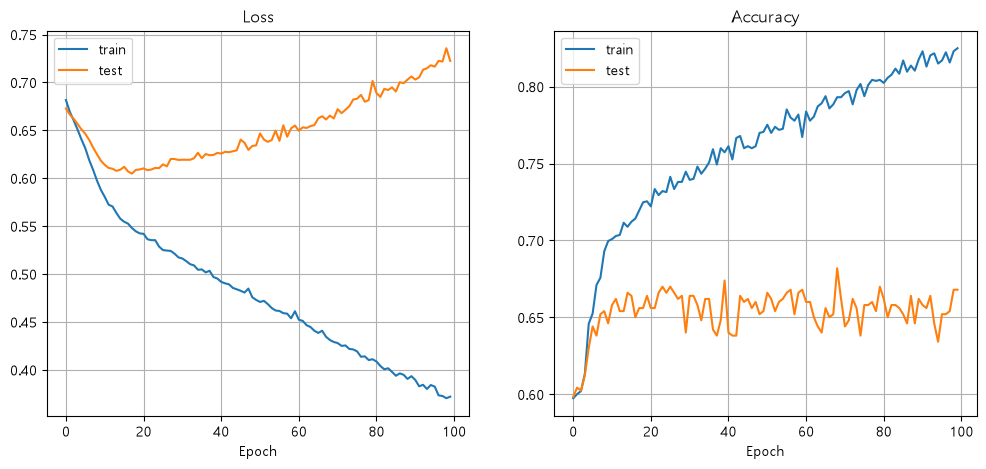

In [ ]:
# 실습 3-2 학습 및 그래프 그려보기

model = Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_zs, y_train, validation_data=(x_test_zs, y_test), epochs=100)

learning_plot(hist)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,785 (18.69 KB)

 Trainable params: 4,785 (18.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5729 - loss: 0.6825 - val_accuracy: 0.5964 - val_loss: 0.6748
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6008 - loss: 0.6687 - val_accuracy: 0.5944 - val_loss: 0.6647
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6273 - loss: 0.6542 - val_accuracy: 0.6282 - val_loss: 0.6519
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6724 - loss: 0.6259 - val_accuracy: 0.6541 - val_loss: 0.6326
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6850 - loss: 0.6001 - val_accuracy: 0.6978 - val_loss: 0.6071
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7029 - loss: 0.5768 - val_accuracy: 0.6859 - val_loss: 0.5955
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7155 - loss: 0.5637 - val_accuracy: 0.6918 - val_loss: 0.5998
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7122 - loss: 0.5534 - val_accuracy: 0.6759 - 

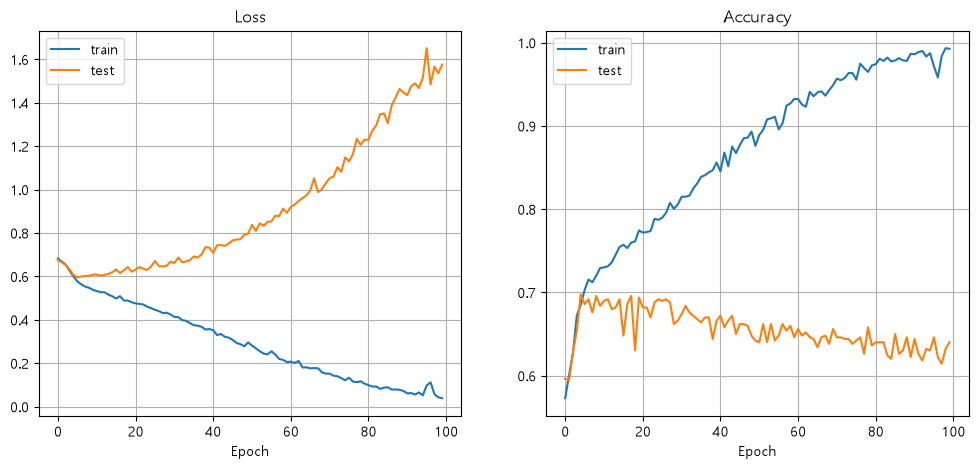

In [ ]:
# 실습 3-3 Dropout 적용 여부(없을 경우)

model = Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_zs, y_train, validation_data=(x_test_zs, y_test), epochs=100)

learning_plot(hist)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,785 (18.69 KB)

 Trainable params: 4,785 (18.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5411 - loss: 0.6874 - val_accuracy: 0.6123 - val_loss: 0.6759
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6048 - loss: 0.6741 - val_accuracy: 0.6143 - val_loss: 0.6675
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6187 - loss: 0.6626 - val_accuracy: 0.6382 - val_loss: 0.6563
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6399 - loss: 0.6513 - val_accuracy: 0.6561 - val_loss: 0.6377
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6558 - loss: 0.6301 - val_accuracy: 0.6680 - val_loss: 0.6212
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6611 - loss: 0.6228 - val_accuracy: 0.6759 - val_loss: 0.6155
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6784 - loss: 0.6087 - val_accuracy: 0.6799 - val_loss: 0.6060
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6857 - loss: 0.5906 - val_accuracy: 0.6839 - 

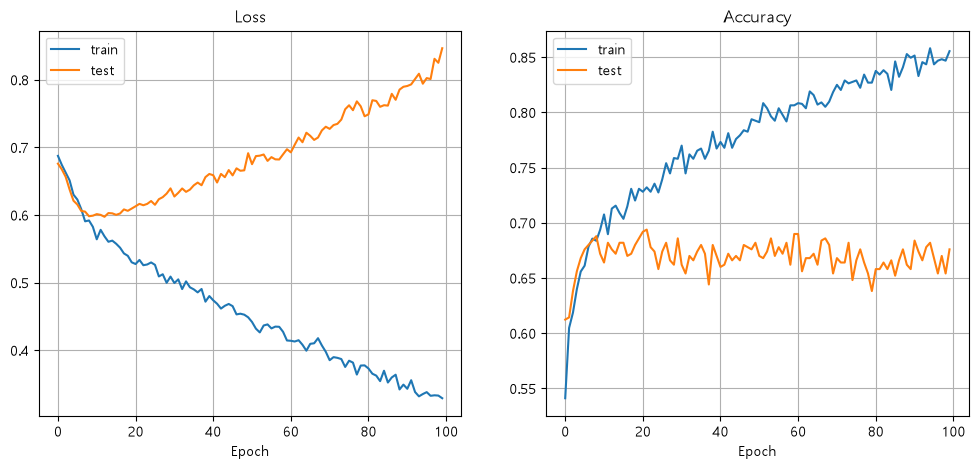

In [ ]:
# 실습 3-3 Dropout 적용 여부(있을 경우)

model = Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))                   # 64와 32 로 넘어가는 과정에서 30% 씩 학습에 참여하지 않게 함
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss = 'binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_zs, y_train, validation_data=(x_test_zs, y_test), epochs=100)

learning_plot(hist)

In [ ]:
# 실습 3-4 Softmax 적용 준비

y_train_oh = to_categorical(y_train) # one-hot
y_test_oh = to_categorical(y_test)

print(y_train[:5])
print(y_train_oh[:5])

419     0
30      0
1549    1
2973    0
163     0
Name: Potability, dtype: int64
[[1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,794 (18.73 KB)

 Trainable params: 4,794 (18.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5855 - loss: 0.6830 - val_accuracy: 0.5984 - val_loss: 0.6686
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5995 - loss: 0.6602 - val_accuracy: 0.6103 - val_loss: 0.6504
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6088 - loss: 0.6535 - val_accuracy: 0.6203 - val_loss: 0.6457
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6167 - loss: 0.6390 - val_accuracy: 0.6203 - val_loss: 0.6374
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6472 - loss: 0.6255 - val_accuracy: 0.6421 - val_loss: 0.6289
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6446 - loss: 0.6194 - val_accuracy: 0.6441 - val_loss: 0.6275
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6810 - loss: 0.6032 - val_accuracy: 0.6620 - val_loss: 0.6196
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6724 - loss: 0.6021 - val_accuracy: 0.6461 - 

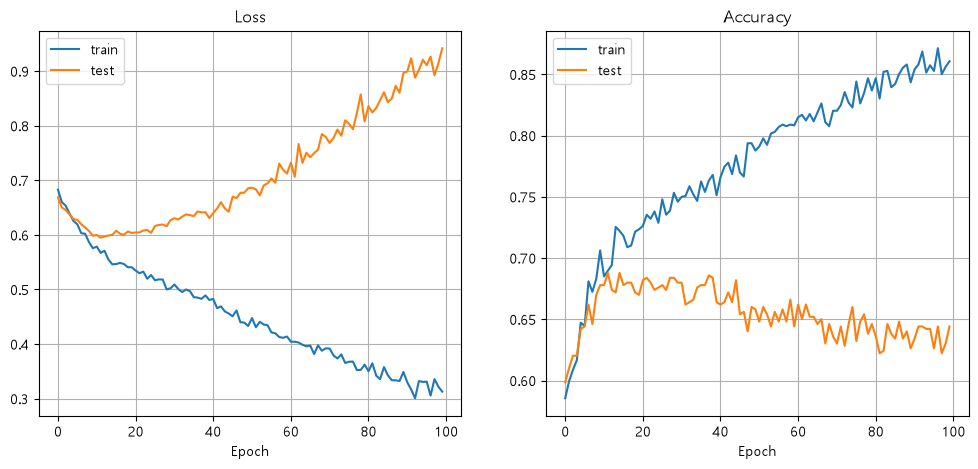

In [ ]:
# 실습 3-5 Softmax 적용(one-hot encoding)

model = Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(2, activation='softmax'))  # Shape 값아야 적용해줄 수 있음
model.summary()

model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_zs, y_train_oh, validation_data=(x_test_zs, y_test_oh), epochs=100)

learning_plot(hist)

# 실습 Mnist

In [ ]:
# 실습 1-0 데이터 불러오기

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (10000,)


5


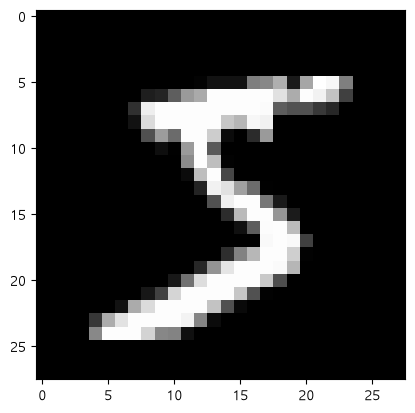

In [ ]:
# 실습 1-1 데이터 확인

print(y_train[0])
plt.imshow(x_train[0], cmap = 'gray')
plt.show()

In [34]:
x_train_1d = x_train.reshape(60000,-1)
x_test_1d = x_test.reshape(10000,-1)
print(x_train_1d.shape, x_test_1d.shape)

(60000, 784) (10000, 784)


In [36]:
np.min(x_train_1d), np.max(x_train_1d)

(np.uint8(0), np.uint8(255))

## 2. 전처리

In [ ]:
# 실습 1-2 전처리 
# 0~255 라서 그냥 255로 나눠주면 Min-Max 가 됨

x_train_1d = x_train.reshape(60000,-1) /255
x_test_1d = x_test.reshape(10000,-1) / 255
print(x_train_1d.shape, x_test_1d.shape)

(60000, 784) (10000, 784)


In [38]:
np.min(x_train_1d), np.max(x_train_1d)

(np.float64(0.0), np.float64(1.0))

In [ ]:
# 1-3 one-hot encoding

y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [41]:
y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)
print(y_train_oh.shape, y_test_oh.shape)

(60000, 10) (10000, 10)


In [42]:
y_train_oh[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

## 3. 예측 모델

### 첫 은닉층 유닛 수를 정하는 기준

- **2의 거듭제곱 사용**: 32, 64, 128, 256, 512 등 — GPU 연산 효율로 해당 값 사용. 정확히 몇 배로 줄일지는 정해진 규칙이 없습니다.(실무에선 경험적으로 도출 필요)
- **점진적 축소(funnel 구조)**: 입력 → 출력으로 갈수록 서서히 줄이되, 한 번에 너무 크게 줄이지 않는 정도의 감각적 기준.
- **Jeff Heaton의 경험칙**: 은닉층 유닛 수를 대략 `(입력 수 + 출력 수) × 2/3` 정도로 잡으라는 식. MNIST에 대입하면 `(784+10) × 2/3 ≈ 529` 정도로, 256보다 큽니다.
- **결국은 실험**: 정확한 유닛 수/층 수는 이런 감각으로 시작한 뒤, validation accuracy/loss를 보면서 늘리거나 줄이며 튜닝하는 게 일반적.

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_31 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9031 - loss: 0.3185 - val_accuracy: 0.9638 - val_loss: 0.1247
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9535 - loss: 0.1557 - val_accuracy: 0.9683 - val_loss: 0.1055
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9632 - loss: 0.1265 - val_accuracy: 0.9743 - val_loss: 0.0883
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9669 - loss: 0.1110 - val_accuracy: 0.9761 - val_loss: 0.0784
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9703 - loss: 0.0984 - val_accuracy: 0.9755 - val_loss: 0.0805
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9738 - loss: 0.0860 - val_accuracy: 0.9799 - val_loss: 0.0671
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9760 - loss: 0.0800 - val_accuracy: 0.9804 - val_loss: 0.0712
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9775 - loss: 0

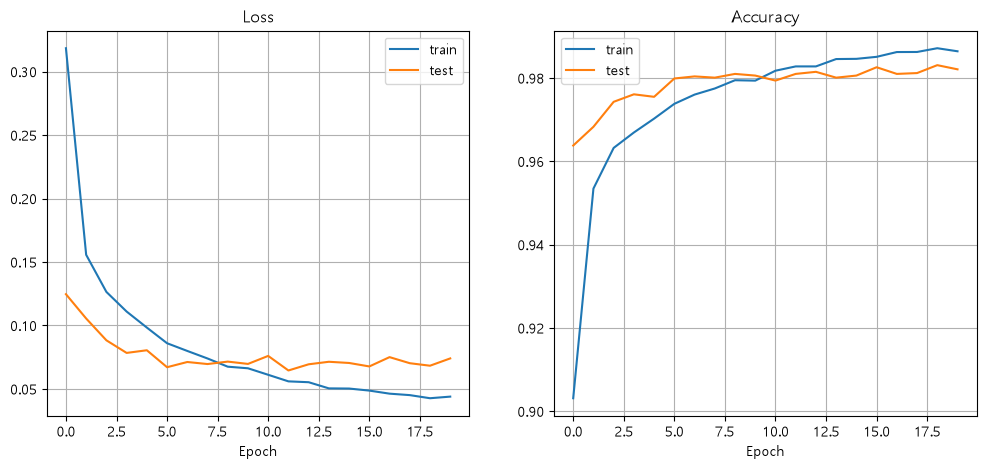

In [ ]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(256, activation='relu'))   # 입력 차원(784)보다 줄이되 정보 손실이 크지 않도록 약 1/3 크기로 시작합니다
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))   # 각 층이 이전 층 정보를 완만하게 압축·재조합
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(x_train_1d, y_train_oh, validation_data=(x_test_1d, y_test_oh), epochs=20)

learning_plot(hist)

# 제프 히튼의 신경망 설계 경험칙 (Jeff Heaton's Rule of Thumb)

인공신경망 모델의 은닉층 개수와 뉴런 개수를 결정할 때 사용하는 실무 지침입니다.

---

## 1. 은닉층 개수 (Number of Hidden Layers)

### 0개 은닉층
- **사용 조건**: 데이터가 선형 분리(Linearly Separable)가 가능할 때
- **의미**: 직선 하나로 정답을 완벽히 나눌 수 있는 단순한 문제

### 1개 은닉층
- **가장 일반적인 선택**
- **적용 대상**: 대부분의 일반적인 데이터 분석 문제
- **원리**: 보편적 근사 정리(Universal Approximation Theorem)에 의해 하나의 은닉층만으로도 대다수의 연속 함수 관계를 근사할 수 있음

### 2개 은닉층
- **사용 조건**: 결정 경계(Decision Boundary)가 매우 복잡하고 굴곡이 심할 때
- **특징**: 임의의 복잡한 모양도 거의 모두 표현 가능

### 3개 이상 (딥러닝 영역)
- **적용 대상**: 컴퓨터 비전(이미지), 시계열, 자연어 처리 등 극도로 복잡한 데이터
- **주의**: 일반적인 정형 데이터 분석에서는 거의 불필요
- **부작용**: 층이 많아질수록 학습 속도 저하, 과적합 위험 증가

---

## 2. 은닉층 뉴런 개수 (Number of Hidden Neurons)

### 기본 원칙: 입력과 출력 사이의 크기
은닉층의 뉴런 개수는 **입력층 크기(변수의 개수)**와 **출력층 크기(예측할 정답의 개수)** 사이에 위치하는 것이 정석입니다.

### 2/3 공식 (가장 널리 쓰이는 베이스라인)
은닉층 뉴런 개수는 입력층 크기의 2/3에 출력층 크기를 더한 값으로 시작하는 것이 좋습니다.

$$\text{은닉 뉴런 수} = \left(\text{입력 변수 수} \times \frac{2}{3}\right) + \text{출력 노드 수}$$

**예시**:
- 입력 변수 10개, 출력 노드 3개
- 은닉 뉴런 = (10 × 2/3) + 3 = 6.67 + 3 ≈ **10개**

### 최대 상한선 (과적합 방지)
은닉층 뉴런 개수는 아무리 많아도 **입력층 크기의 2배**보다 작아야 과적합을 방지할 수 있습니다.

$$\text{은닉 뉴런 수} \leq \text{입력 변수 수} \times 2$$

---

## 실무 적용 순서

1. **2/3 공식으로 초기값 설정**
2. **모델 학습 및 검증**
3. **과적합 여부 판단**
   - 과적합이면 뉴런 개수 감소
   - 과소적합이면 뉴런 개수 증가 (상한선 내에서)
4. **하이퍼파라미터 튜닝으로 최적값 찾기**